# Introduction

## Core Concept

An adaptive filter is an optimal filter, with the key difference that optimality is not computed in a one-off manner, but rather recursively,
meaning it gradually converges toward the optimal solution.

While static optimal filters are computed once and for all, in recursive (or block-recursive) approaches, 
the filter coefficients are continuously updated.

This makes them particularly useful for (slowly) non-stationary signals.

Historically, three distinct (though significantly overlapping) approaches have emerged for least-squares (LSE) optimal filters, 
each identified by different names:

## 1) Block Methods (LS – Least Squares)

These correspond to the methods previously referred to as “optimal filters.” They require simultaneous access to all known signal samples (a complete data block).
### Pros
* They work very well
* Good performance
### Cons
* High computational cost
* Significant delay (which is a consequence of the high computational cost)
  
For example, designing an optimal FIR filter requires solving a system of linear equations, i.e., inverting a matrix.
The computational complexity is at most proportional to the cube of the dimension, O(N³).

## 2) Recursive Methods (Online, LMS – Least Mean Squares)

At the opposite extreme of approach 1), fully recursive methods exist, where optimality is approached asymptotically: at each step, incremental computations are performed, and after processing a substantial portion of the signal, the optimal solution is reached.

<< Historically, this approach is known as LMS >>

Often categorized under “adaptive filters.” They do not require knowledge of the entire signal, only a small portion (even a single sample).


### Pros
* Low computational cost → complexity O(N)
* Fast execution
### Cons
* Convergence issues: optimality is not guaranteed to be reached and for sure not immediately.


## 3) Block-Recursive Methods (RLS – Recursive Least Squares)

These lie midway between approaches 1) and 2).

Require higher computational cost than LMS → complexity O(N²)
Lower delay compared to batch LS

## Notes about approaches
Methods 2) and 3) can also be applied to (slowly) non-stationary signals.
The below stated computational complexities are rough approximations (order-of-magnitude estimates), not exact values, but they provide a useful comparative perspective:

1) → O(N³)

2) → O(N)

3) → O(N²)

In the context of discrete-time signal processing, recursive algorithms are extensively used due:
* low computational cost;
* online adaptation capability, which enables tracking of non-stationarities.

Being inherently online, if the characteristics of the target system change (i.e., the optimal solution shifts), 
the filter gradually adapts to the new optimum → a critical feature for many practical applications.

In DSP applications, the LMS algorithm remains the most widely used.

# Adaptation Strategies

## Open-Loop (Blind)

There is considerable interest in blind strategies. In this approach, adaptation relies exclusively on the characteristics of the input signal. 
For example, if the objective is to obtain a whitened signal, we analyze the input spectrum, identify spectral coloration (e.g., “this region is colored and requires attenuation; that region is acceptable”), and implement the necessary compensation by adjusting the filter’s poles and zeros.

<img src="images/open_loop_operator_diagram.svg" style="width:50%">

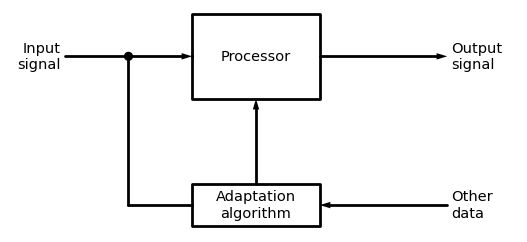

In [65]:
import schemdraw
import schemdraw.elements as elm
import schemdraw.dsp as dsp
from schemdraw.util import Point

with schemdraw.Drawing(fontsize=12) as d:
    u = d.unit

    # ── Input signal → dot → Processor → Output (all chained, no .at) ──
    d += elm.Line().right(u/2).label('Input\nsignal', loc='left')
    dot = d.add(elm.Dot())
    d += elm.Arrow().right(u/2)
    proc = d.add(dsp.Box(w=3, h=2).anchor('W').label('Processor'))
    d += elm.Arrow().right(u).at(proc.E).label('Output\nsignal', loc='right')

    # ── Adaptation algorithm box, placed below Processor ────────────────
    adapt = d.add(dsp.Box(w=3, h=1).anchor('N').at((proc.S[0], proc.S[1]-2)).label('Adaptation\nalgorithm'))

    # arrow up into Processor's south anchor
    d += elm.Arrow().up().at(adapt.N).to(proc.S)

    # ── Branch wire: dot down, then across to adaptation box ─────────────
    d += elm.Line().down().at(dot.center).toy(adapt.W)
    d += elm.Line().tox(adapt.W)

    # ── "Other data" entering from the right ─────────────────────────────
    d.move_from(adapt.E, dx=u)
    d += elm.Arrow().left(u).label('Other\ndata', loc='right')

## Closed-Loop (Supervised)

This corresponds to the scenario already discussed, where the performance metric is derived from the error signal and the desired 
output signal must be available.

<img src="images/closed_loop_operator_diagram.svg" style="width:50%">

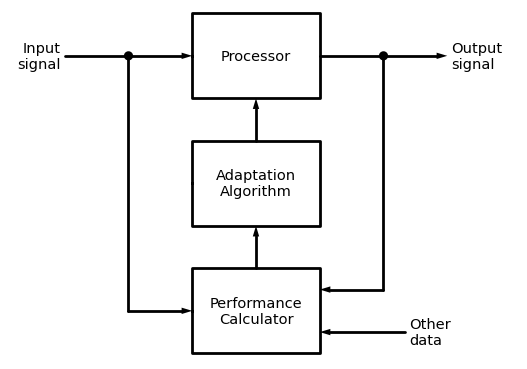

In [68]:
import schemdraw
import schemdraw.elements as elm
import schemdraw.dsp as dsp

with schemdraw.Drawing(fontsize=12) as d:
    u = d.unit
    gap = 1.0  # vertical gap between stacked boxes — gives connecting arrows real length
    
    # ── Main signal path: Input → Processor → Output ──
    d += elm.Line().right(u/2).label('Input\nsignal', loc='left')
    dot_in = d.add(elm.Dot())
    d += elm.Arrow().right(u/2)
    proc = d.add(dsp.Box(w=3, h=2).anchor('W').label('Processor'))
    d += elm.Line().right(u/2).at(proc.E)
    dot_out = d.add(elm.Dot())
    d += elm.Arrow().right(u/2).label('Output\nsignal', loc='right')
   
    # ── Feedback chain below: Adaptation Algorithm → Performance Calculator ──
    adapt = d.add(dsp.Box(w=3, h=2).anchor('N')
                  .at((proc.S[0], proc.S[1] - gap))
                  .label('Adaptation\nAlgorithm'))
    d += elm.Arrow().at(adapt.N).to(proc.S)

    perf = d.add(dsp.Box(w=3, h=2).anchor('N')
                 .at((adapt.S[0], adapt.S[1] - gap))
                 .label('Performance\nCalculator'))
    d += elm.Arrow().at(perf.N).to(adapt.S)

    # ── Feedback taps into Performance Calculator ──
    d += elm.Line().down().at(dot_in.center).toy(perf.W)
    d += elm.Arrow().to(perf.W)

    perf_e_upper = (perf.E[0], perf.E[1] + 0.5)
    d += elm.Line().at(dot_out.center).to((dot_out.center[0], perf_e_upper[1]))
    d += elm.Arrow().to(perf_e_upper)

    # ── External input: Other data ──
    perf_e_lower = (perf.E[0], perf.E[1] - 0.5)
    d += (elm.Arrow().at((perf_e_lower[0] + 2, perf_e_lower[1]))
          .to(perf_e_lower)
          .label('Other\ndata', loc='right'))